In [1]:
!pip install faker

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 36.5 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
from faker import Faker
import random
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [3]:
fake = Faker()

data = []

for i in range(100000):
    age = random.randint(18, 70)
    tenure = random.randint(0, 10)
    balance = round(random.uniform(0, 200000), 2)
    credit_score = random.randint(300, 900)
    salary = round(random.uniform(10000, 150000), 2)
    products = random.randint(1, 4)
    active = random.choice([0, 1])
    churn = 0
    if (balance < 50000 and active == 0) or (credit_score < 500 and products == 1):
        churn = 1

    data.append([
        i, age, random.choice(['Male', 'Female']), tenure,
        balance, credit_score, salary, products, active, churn
    ])

columns = [
    'Customer_ID', 'Age', 'Gender', 'Tenure', 'Balance',
    'CreditScore', 'EstimatedSalary', 'NumOfProducts',
    'IsActiveMember', 'Churn'
]

df = pd.DataFrame(data, columns=columns)

df.head()

,Customer_ID,Age,Gender,Tenure,Balance,CreditScore,EstimatedSalary,NumOfProducts,IsActiveMember,Churn
0,0,36,Male,0,127753.56,518,14452.60,1,0,0
1,1,24,Female,9,62451.00,492,22309.74,3,1,0
2,2,69,Male,10,81777.01,647,83445.13,4,0,0
3,3,62,Male,5,38784.35,322,98575.49,3,1,0
4,4,66,Male,4,73633.99,587,65500.37,2,1,0


In [4]:
print(df.info())
print(df.isnull().sum())
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Customer_ID      100000 non-null  int64  
 1   Age              100000 non-null  int64  
 2   Gender           100000 non-null  object 
 3   Tenure           100000 non-null  int64  
 4   Balance          100000 non-null  float64
 5   CreditScore      100000 non-null  int64  
 6   EstimatedSalary  100000 non-null  float64
 7   NumOfProducts    100000 non-null  int64  
 8   IsActiveMember   100000 non-null  int64  
 9   Churn            100000 non-null  int64  
dtypes: float64(2), int64(7), object(1)
memory usage: 7.6+ MB
None
Customer_ID        0
Age                0
Gender             0
Tenure             0
Balance            0
CreditScore        0
EstimatedSalary    0
NumOfProducts      0
IsActiveMember     0
Churn              0
dtype: int64


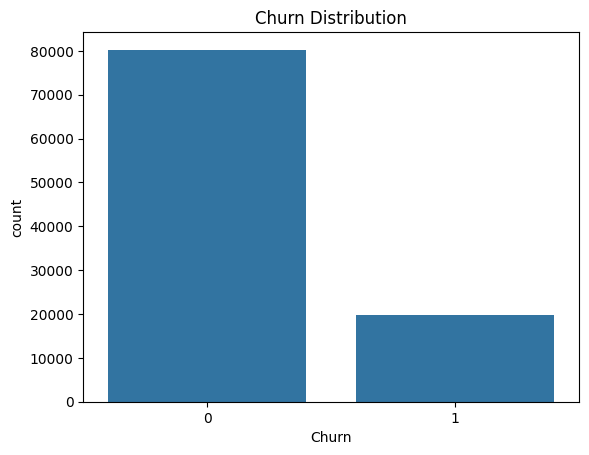

In [5]:
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

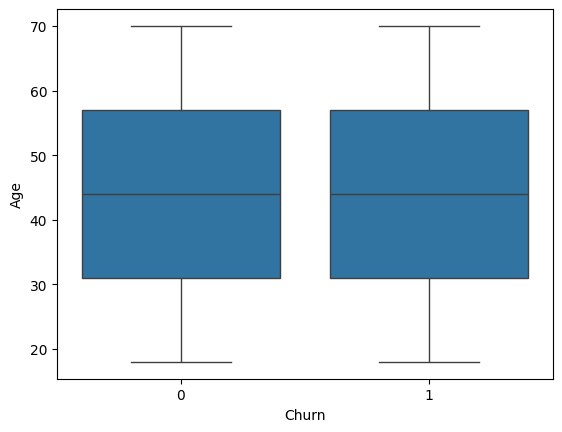

In [6]:
sns.boxplot(x='Churn', y='Age', data=df)
plt.show()

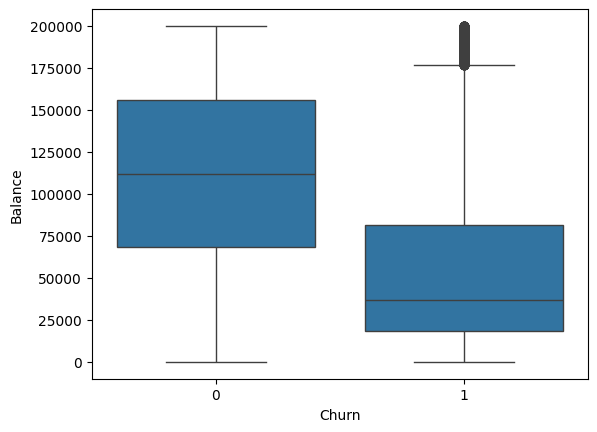

In [7]:
sns.boxplot(x='Churn', y='Balance', data=df)
plt.show()

In [8]:
X = df.drop(['Customer_ID', 'Churn'], axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

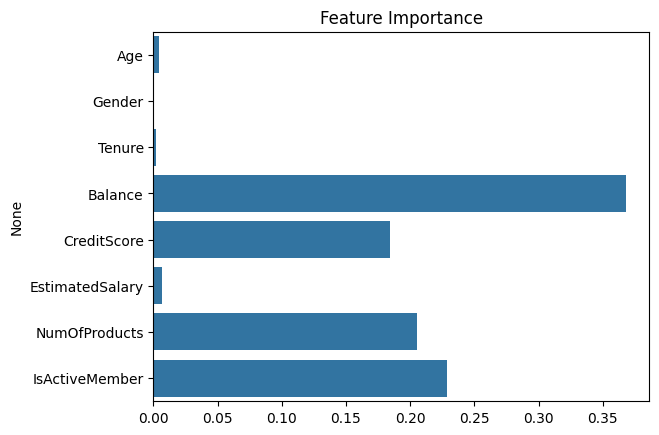

In [9]:
importances = model.feature_importances_
features = X.columns

sns.barplot(x=importances, y=features)
plt.title("Feature Importance")
plt.show()